In [13]:
import pandas as pd
import sqlite3

In [14]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [15]:
query = """
SELECT timestamp
FROM checker
WHERE uid NOT LIKE 'admin_%' AND timestamp IS NOT NULL
"""
df = pd.io.sql.read_sql(query, conn)

In [16]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6])
df['date'] = df['timestamp'].dt.date

In [17]:
hourly = df.groupby(['date', 'is_weekend', 'hour']).size().reset_index(name='commits')
avg = hourly.groupby(['is_weekend', 'hour'])['commits'].mean().reset_index()
pivot = avg.pivot(index='hour', columns='is_weekend', values='commits').fillna(0)
pivot.columns = ['working_day', 'weekend']
pivot = pivot.reindex(range(24), fill_value=0)
pivot.index.name = 'hour'

In [20]:
pivot

,working_day,weekend
hour,,
0,3.000000,2.000000
1,0.000000,6.000000
2,0.000000,0.000000
3,2.000000,1.000000
4,0.000000,0.000000
5,7.500000,2.000000
6,1.500000,0.000000
7,5.166667,4.000000
8,3.700000,7.000000


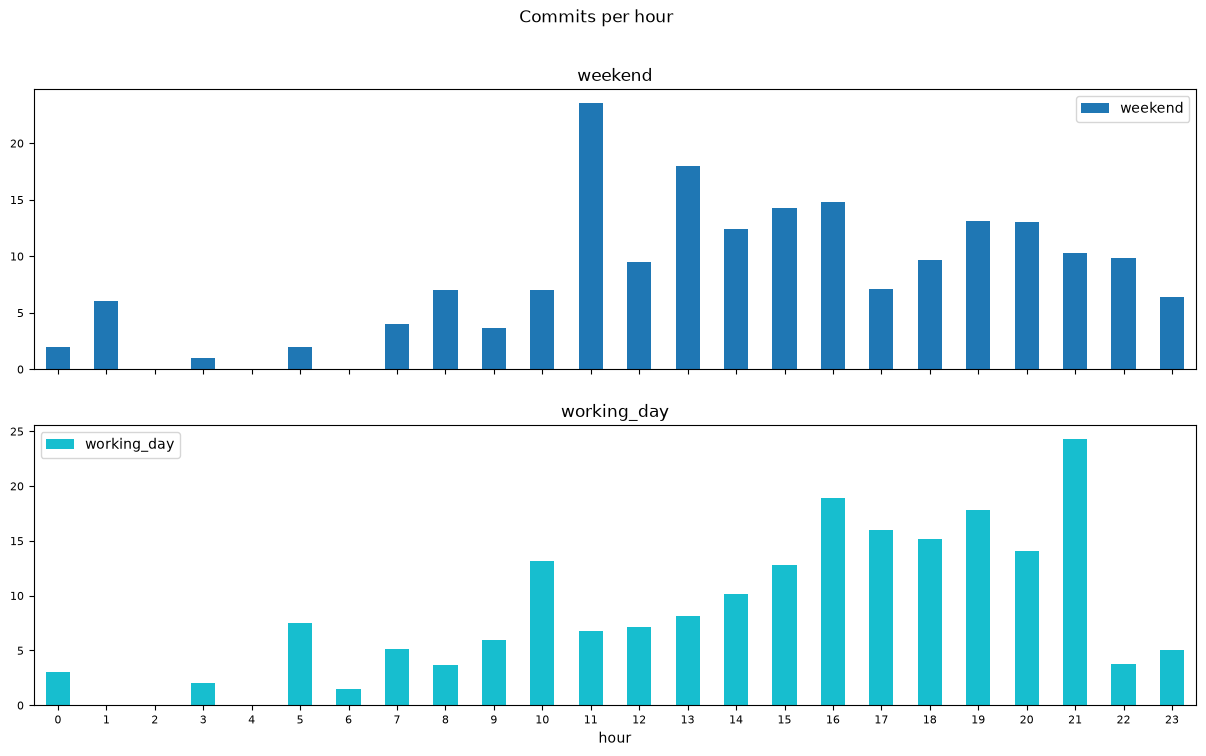

In [18]:
ax = pivot[['weekend', 'working_day']].plot.bar(
    figsize=(15, 8),
    stacked=False,
    colormap='tab10',
    title='Commits per hour',
    fontsize=8,
    rot=0,
    legend=True,
    subplots=True,
    layout=(2, 1)
)

In [19]:
conn.close()

Различается ли динамика в рабочие дни и в выходные?

Ответ: 21 — час с наибольшим числом коммитов в будни; 11 — час с наибольшим числом коммитов в выходные.